# GARCH and VaR backtesting in R: an independent check of the risk engine

The FX notebooks estimate a GJR-GARCH model with Student-t innovations with the C++ engine of `quant_engine` and backtest value at
risk with its own test statistics. This notebook repeats the key steps with **R** on the same ECB reference rates:

| Quantity | R implementation | Python notebook |
| --- | --- | --- |
| Stylised facts of EUR/USD returns (fat tails, volatility clustering) | `tseries::jarque.bera.test`, `Box.test` | `fx_option_desk_hedging` |
| GJR-GARCH(1,1) with Student-t innovations, maximum likelihood | `fGarch::garchFit` (APARCH with power 2) | same notebook |
| Conditional volatility path | `fGarch::volatility` | same notebook |
| 500-day historical-simulation 99% VaR of the currency book | rolling empirical quantile | `fx_garch_var_backtesting` |
| Kupiec and Christoffersen backtests | direct likelihood-ratio formulas | same notebook |

**Requirements.** R 4.2 or later with the packages in `r/install_packages.R` and the IRkernel (see the README). The comparison cells
call the Python package if it is installed (`PYTHON` environment variable, `.venv` in the repository or `python3` on the PATH);
otherwise they are skipped. Data are downloaded into `data/raw/r/`.

In [1]:
suppressPackageStartupMessages({
  library(jsonlite)
  library(ggplot2)
  library(fGarch)
  library(tseries)
})
options(width = 120, repr.plot.width = 10, repr.plot.height = 4.6, repr.plot.res = 110, scipen = 6)

# Repository root: the folder that contains scripts/quant_engine.
find_root <- function() {
  d <- normalizePath(getwd())
  repeat {
    if (dir.exists(file.path(d, "scripts", "quant_engine"))) return(d)
    parent <- dirname(d)
    if (parent == d) stop("run the notebook inside the repository")
    d <- parent
  }
}
ROOT <- find_root()
CACHE <- file.path(ROOT, "data", "raw", "r")   # ignored by Git
dir.create(CACHE, recursive = TRUE, showWarnings = FALSE)

cached_download <- function(url, name) {
  path <- file.path(CACHE, name)
  if (!file.exists(path)) download.file(url, path, quiet = TRUE, mode = "wb")
  path
}

# Results of the Python/C++ engine for the comparison. The code is run with the interpreter in the
# PYTHON environment variable, or .venv in the repository, or python3 on the PATH; it must print JSON.
python_json <- function(code) {
  candidates <- c(Sys.getenv("PYTHON"), file.path(ROOT, ".venv", "bin", "python"),
                  file.path(ROOT, ".venv", "Scripts", "python.exe"), Sys.which("python3"), Sys.which("python"))
  candidates <- candidates[nzchar(candidates) & file.exists(candidates)]
  if (length(candidates) == 0) { message("Python not found: comparison skipped"); return(NULL) }
  script <- tempfile(fileext = ".py")
  writeLines(c("import json, os, sys", sprintf("os.chdir(%s)", deparse(ROOT)), code), script)
  out <- suppressWarnings(system2(candidates[1], script, stdout = TRUE, stderr = FALSE))
  if (!is.null(attr(out, "status")) || length(out) == 0) {
    message("the Python package quant_engine is not available: comparison skipped"); return(NULL)
  }
  fromJSON(paste(out, collapse = "\n"))
}

compare <- function(r, py, label = names(r)) {
  data.frame(quantity = label, R = signif(r, 10), Python = signif(py, 10),
             `abs. difference` = signif(abs(r - py), 3), check.names = FALSE, row.names = NULL)
}

COLORS <- c("#2a78d6", "#eb6834", "#1baf7a", "#eda100")
theme_set(theme_minimal(base_size = 12) +
          theme(panel.grid.minor = element_blank(), plot.title.position = "plot",
                plot.title = element_text(face = "bold"), legend.position = "top"))
cat(R.version.string, "| repository:", basename(ROOT), "\n")

ecb_rates <- function() {
  zip <- cached_download("https://www.ecb.europa.eu/stats/eurofxref/eurofxref-hist.zip", "eurofxref-hist.zip")
  f <- read.csv(unz(zip, "eurofxref-hist.csv"), na.strings = c("N/A", ""), check.names = FALSE)
  f <- f[, names(f) != "" & !startsWith(names(f), "V")]
  f$Date <- as.Date(f$Date)
  f[order(f$Date), ]
}
END <- as.Date("2025-12-31")

R version 4.3.3 (2024-02-29) | repository: Quantitative-finance 


## 1. EUR/USD returns and stylised facts

In [2]:
rates <- ecb_rates()
usd <- rates[rates$Date <= END & !is.na(rates$USD), c("Date", "USD")]
r <- 100 * diff(log(usd$USD))
moments <- c(n = length(r), `annualised volatility (%)` = sd(r) * sqrt(252),
             skewness = mean((r - mean(r))^3) / sd(r)^3, `excess kurtosis` = mean((r - mean(r))^4) / sd(r)^4 - 3)
print(round(moments, 3))
jb <- jarque.bera.test(r); lb <- Box.test(r, lag = 20, type = "Ljung-Box"); lb2 <- Box.test(r^2, lag = 20, type = "Ljung-Box")
data.frame(test = c("Jarque-Bera (normality)", "Ljung-Box, returns, 20 lags", "Ljung-Box, squared returns, 20 lags"),
           statistic = c(jb$statistic, lb$statistic, lb2$statistic), `p-value` = c(jb$p.value, lb$p.value, lb2$p.value),
           check.names = FALSE)

                        n annualised volatility (%)                  skewness           excess kurtosis 
                 6912.000                     9.298                     0.043                     3.248 


test,statistic,p-value
<chr>,<dbl>,<dbl>
Jarque-Bera (normality),3044.70438,0.000000000
"Ljung-Box, returns, 20 lags",39.83716,0.005237576
"Ljung-Box, squared returns, 20 lags",1218.89227,0.000000000


## 2. GJR-GARCH(1,1) with Student-t innovations

`fGarch` parametrises asymmetry as an APARCH model, $\\sigma_t^2 = \\omega + \\alpha\\,(|\\varepsilon_{t-1}| - \\gamma\\,\\varepsilon_{t-1})^2 + \\beta\\,\\sigma_{t-1}^2$
with the power fixed at 2. Expanding the square gives the GJR form
$\\sigma_t^2 = \\omega + (\\alpha_{GJR} + \\gamma_{GJR}\\,1\\{\\varepsilon_{t-1}<0\\})\\,\\varepsilon_{t-1}^2 + \\beta\\,\\sigma_{t-1}^2$ with
$\\alpha_{GJR} = \\alpha (1-\\gamma)^2$ and $\\gamma_{GJR} = 4\\alpha\\gamma$. Both estimators maximise the exact likelihood but start the variance
recursion and search the optimum differently, so agreement is expected to a few percent on each parameter rather than to machine
precision; the persistence and the implied long-run volatility are the economically relevant checks. The mean return is
statistically zero (standard error about 0.006), so its relative difference is not meaningful.

In [3]:
fit <- suppressWarnings(garchFit(~ aparch(1, 1), data = r, cond.dist = "std", include.delta = FALSE, delta = 2,
                                 include.mean = TRUE, trace = FALSE))
cf <- coef(fit)
gjr <- c(mu = unname(cf["mu"]), omega = unname(cf["omega"]), alpha = unname(cf["alpha1"] * (1 - cf["gamma1"])^2),
         gamma = unname(4 * cf["alpha1"] * cf["gamma1"]), beta = unname(cf["beta1"]), nu = unname(cf["shape"]))
persistence <- gjr[["alpha"]] + gjr[["gamma"]] / 2 + gjr[["beta"]]
long_run <- sqrt(gjr[["omega"]] / (1 - persistence) * 252)
r_values <- c(gjr, persistence = persistence, `long-run volatility (%)` = long_run, `log-likelihood` = -unname(fit@fit$llh))
py <- python_json('
import numpy as np
from quant_engine import data, garch, risk
fx = data.load_ecb_fx_rates(("USD",), end="2025-12-31")["USD"].dropna()
r = 100 * np.log(fx).diff().dropna()
fit = garch.fit(r, "gjr", "t")
p = fit.params
s2 = garch.conditional_variance(r, p, "gjr", "t")
rates = data.load_ecb_fx_rates(("USD", "GBP", "JPY", "CHF"), start="1999-01-04", end="2025-12-31").dropna()
port = 100 * np.log1p((rates.shift(1) / rates - 1.0).mean(axis=1)).dropna()
hs = risk.historical_var_es(port, 500, 0.01)
hits = (-port.reindex(hs.index) > hs["var"]).to_numpy()
print(json.dumps({"n": int(len(r)), "params": {k: float(v) for k, v in p.items()}, "persistence": fit.persistence,
                  "loglik": fit.loglik, "sigma": np.sqrt(s2[:-1]).tolist(), "var": hs["var"].tolist(),
                  "kupiec": {k: float(v) for k, v in risk.kupiec_pof(hits, 0.01).items()},
                  "christoffersen": {k: float(v) for k, v in risk.christoffersen_independence(hits).items()}}))
')
if (!is.null(py)) {
  p <- py$params
  py_values <- c(p$mu, p$omega, p$alpha, p$gamma, p$beta, p$nu, py$persistence,
                 sqrt(p$omega / (1 - py$persistence) * 252), py$loglik)
  out <- compare(r_values, py_values, names(r_values))
  out$`relative difference` <- signif(abs(r_values - py_values) / abs(py_values), 3)
  cat("Observations: R", length(r), "| Python", py$n, "\n")
  out
} else round(r_values, 5)

Observations: R 6912 | Python 6912 


quantity,R,Python,abs. difference,relative difference
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
mu,-0.00004751449,0.0002759681,0.0003230000,1.17000000
omega,0.00069292857,0.0006929934,0.0000000648,0.00009360
alpha,0.02688041456,0.0268967832,0.0000164000,0.00060900
gamma,0.00553259729,0.0055019173,0.0000307000,0.00558000
beta,0.96879708590,0.9687934322,0.0000036500,0.00000377
nu,7.27050203700,7.2700934910,0.0004090000,0.00005620
persistence,0.99844379910,0.9984411740,0.0000026300,0.00000263
long-run volatility (%),10.59282187000,10.5843941600,0.0084300000,0.00079600
log-likelihood,-5473.95033400000,-5473.9488550000,0.0014800000,0.00000027


Conditional volatility, annualised: median abs. difference 0.0003 points, correlation 1.000000


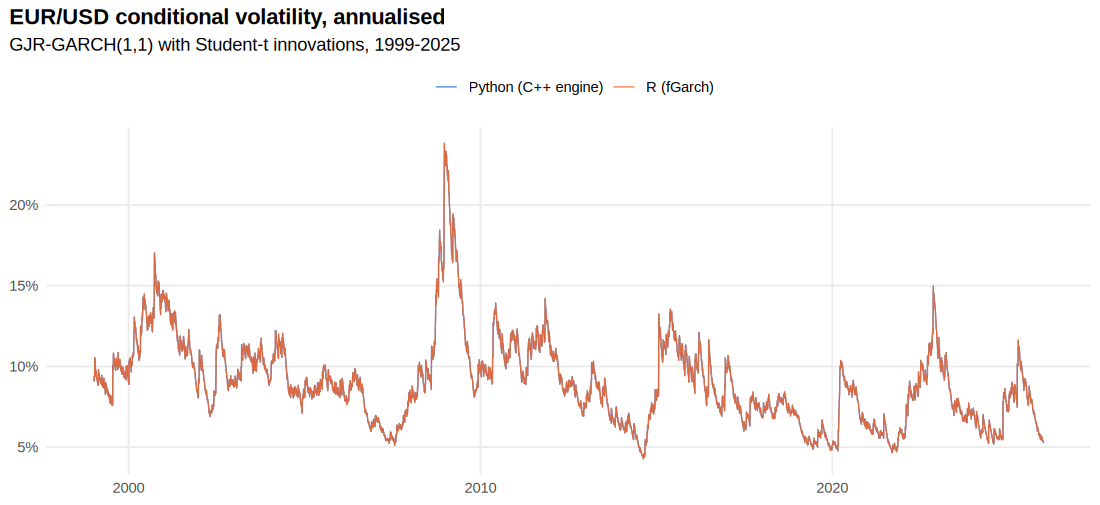

In [4]:
if (!is.null(py)) {
  vol <- data.frame(date = rep(usd$Date[-1], 2), vol = c(volatility(fit), py$sigma) * sqrt(252),
                    source = rep(c("R (fGarch)", "Python (C++ engine)"), each = length(r)))
  cat(sprintf("Conditional volatility, annualised: median abs. difference %.4f points, correlation %.6f\n",
              median(abs(volatility(fit) - py$sigma)) * sqrt(252), cor(volatility(fit), py$sigma)))
  ggplot(vol, aes(date, vol, colour = source)) + geom_line(linewidth = 0.4, alpha = 0.9) +
    scale_colour_manual(values = COLORS[1:2]) + scale_y_continuous(labels = function(v) paste0(v, "%")) +
    labs(title = "EUR/USD conditional volatility, annualised", subtitle = "GJR-GARCH(1,1) with Student-t innovations, 1999-2025",
         x = NULL, y = NULL, colour = NULL)
}

## 3. Historical-simulation VaR and regulatory backtests

Currency book: equal weights in USD, GBP, JPY and CHF against the euro; one-day 99% VaR as the empirical 1% quantile of the previous 500
returns (linear interpolation, R type 7 = NumPy default). Kupiec (1995) tests the exception rate; Christoffersen (1998) tests the
independence of exceptions with a first-order Markov chain.

In [5]:
fx <- rates[rates$Date >= as.Date("1999-01-04") & rates$Date <= END, c("Date", "USD", "GBP", "JPY", "CHF")]
fx <- fx[complete.cases(fx), ]
m <- as.matrix(fx[, -1])
simple <- m[-nrow(m), ] / m[-1, ] - 1
port <- 100 * log1p(rowMeans(simple))
window <- 500
var_hs <- sapply((window + 1):length(port), function(t) -quantile(port[(t - window):(t - 1)], 0.01, type = 7, names = FALSE))
realised <- port[(window + 1):length(port)]
hits <- as.integer(-realised > var_hs)
kupiec <- function(h, a) {
  n <- length(h); x <- sum(h); p <- x / n
  lr <- -2 * ((n - x) * log1p(-a) + x * log(a) - ((n - x) * log1p(-p) + x * log(p)))
  c(exceptions = x, rate = p, lr = lr, p_value = pchisq(lr, 1, lower.tail = FALSE))
}
christoffersen <- function(h) {
  prev <- head(h, -1); curr <- tail(h, -1)
  n00 <- sum(prev == 0 & curr == 0); n01 <- sum(prev == 0 & curr == 1); n10 <- sum(prev == 1 & curr == 0); n11 <- sum(prev == 1 & curr == 1)
  xl <- function(x, y) if (x > 0) x * log(y) else 0
  p0 <- n01 / (n00 + n01); p1 <- n11 / (n10 + n11); p <- (n01 + n11) / (n00 + n01 + n10 + n11)
  lr <- -2 * (xl(n00 + n10, 1 - p) + xl(n01 + n11, p) - (xl(n00, 1 - p0) + xl(n01, p0) + xl(n10, 1 - p1) + xl(n11, p1)))
  c(pi01 = p0, pi11 = p1, lr = lr, p_value = pchisq(lr, 1, lower.tail = FALSE))
}
k <- kupiec(hits, 0.01); ch <- christoffersen(hits)
res <- data.frame(quantity = c("exceptions", "exception rate", "Kupiec LR", "Kupiec p-value", "Christoffersen LR", "Christoffersen p-value"),
                  R = c(k[["exceptions"]], k[["rate"]], k[["lr"]], k[["p_value"]], ch[["lr"]], ch[["p_value"]]))
if (!is.null(py)) {
  res$Python <- c(py$kupiec$exceptions, py$kupiec$rate, py$kupiec$lr, py$kupiec$p_value, py$christoffersen$lr, py$christoffersen$p_value)
  cat(sprintf("VaR series: %d days, max abs. difference R vs Python %.2e (percentage points)\n",
              length(var_hs), max(abs(var_hs - py$var))))
}
res

VaR series: 6412 days, max abs. difference R vs Python 2.22e-16 (percentage points)


quantity,R,Python
<chr>,<dbl>,<dbl>
exceptions,83.00000000,83.00000000
exception rate,0.01294448,0.01294448
Kupiec LR,5.13819954,5.13819954
Kupiec p-value,0.02340491,0.02340491
Christoffersen LR,2.40114414,2.40114414
Christoffersen p-value,0.12124654,0.12124654


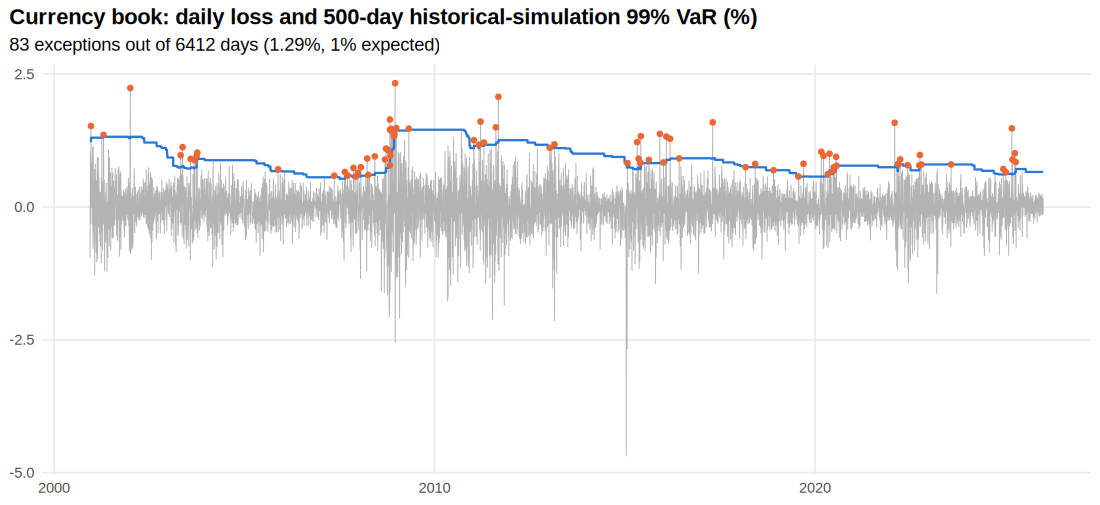

In [6]:
bt <- data.frame(date = fx$Date[-1][(window + 1):length(port)], loss = -realised, var = var_hs, hit = hits == 1)
ggplot(bt, aes(date)) + geom_line(aes(y = loss), colour = "grey70", linewidth = 0.3) +
  geom_line(aes(y = var), colour = COLORS[1], linewidth = 0.7) +
  geom_point(data = bt[bt$hit, ], aes(y = loss), colour = COLORS[2], size = 1.4) +
  labs(title = "Currency book: daily loss and 500-day historical-simulation 99% VaR (%)",
       subtitle = sprintf("%d exceptions out of %d days (%.2f%%, 1%% expected)", sum(hits), length(hits), 100 * mean(hits)),
       x = NULL, y = NULL)

## 4. Conclusions

- The R estimates of the GJR-GARCH-t model agree with the C++ engine on persistence, long-run volatility and the shape of the Student-t
  distribution, and the conditional volatility paths are practically indistinguishable; the small differences in individual
  parameters come from the variance initialisation and the optimiser, not from the model.
- The historical-simulation VaR series and the Kupiec and Christoffersen statistics computed in R coincide with the Python risk module.
  The backtest conclusions of the risk notebook therefore rest on independently verified numbers.

### References

- Christoffersen, P. F. (1998). Evaluating interval forecasts. *International Economic Review*, 39(4), 841-862.
- Ding, Z., Granger, C. W. J. and Engle, R. F. (1993). A long memory property of stock market returns and a new model. *Journal of Empirical Finance*, 1(1), 83-106.
- Glosten, L. R., Jagannathan, R. and Runkle, D. E. (1993). On the relation between the expected value and the volatility of the nominal excess return on stocks. *Journal of Finance*, 48(5), 1779-1801.
- Kupiec, P. H. (1995). Techniques for verifying the accuracy of risk measurement models. *Journal of Derivatives*, 3(2), 73-84.
- Wuertz, D. et al. fGarch: Rmetrics - autoregressive conditional heteroskedastic modelling. R package.